### Входная цепь радиоприёмного устройства

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import math

# Семён
# Исходные данные вариант 15
f0 = 53e6       # Гц
Lk = 0.930e-6   # Гн
Rn = 1.1e3      # Ом
m = 0.40
Ra = 200        # Ом
P_ke = 7.5e6    # Гц
R_k = 6.8e3     # Ом
Rk = 6.8e3

# Гэсэр
# f0 = 48e6       # Гц
# Lk = 1.21e-6   # Гн
# Rn = 1.3e3      # Ом
# m = 0.39
# Ra = 250        # Ом
# P_ke = 7.1e6    # Гц
# R_k = 5.8e3     # Ом
# Rk = 5.8e3     # Ом

# Шаг 1: Расчет параметров колебательного контура
Ck = 1 / ((2 * math.pi * f0)**2 * Lk)
gk = 1 / Rk
gn = 1 / Rn
gk_eq = gk + m**2 * gn
Rk_eq = 1 / gk_eq

# Индуктивность катушки связи для k_sv = 0.4 и 0.8
k_sv_list = [0.4, 0.8]
Lsv_list = [( (m / k_sv)**2 * Lk ) for k_sv in k_sv_list]

# Шаг 2: Параметры ВЦ в режиме согласования
# Собственная полоса пропускания
Pk = 1 / (2 * math.pi * R_k * Ck)
# Коэффициент расширения полосы
kp = P_ke / Pk
# Проводимость антенны
ga = 1 / Ra
# Коэффициенты включения (предположим правильную формулу)
m1c = math.sqrt((kp * gk) / (2 * ga)) 
m2c = math.sqrt(((kp - 2) * gk) / (2 * gn))
# Резонансный коэффициент передачи
K0c = m2c / (2 * m1c)
# Емкости конденсаторов
C1 = Ck / (1 - m1c)
C2 = Ck / m1c
# Индуктивность катушки связи при k_sv=0.8
k_sv = 0.8
Lsv_08 = (m2c / k_sv)**2 * Lk

# Вывод результатов
print("Результаты расчета для варианта 15:\n")
print("1. Параметры колебательного контура:")
print(f"Ёмкость Ck: {Ck * 1e12} пФ")
print(f"Собственная проводимость gk: {gk * 1e3} мСм")
print(f"Проводимость нагрузки gn: {gn * 1e3} мСм")
print(f"Эквивалентная проводимость gk': {gk_eq * 1e3} мСм")
print(f"Эквивалентное сопротивление Rk': {Rk_eq / 1e3} кОм")
print(f"Индуктивность Lсв (k=0.4): {Lsv_list[0] * 1e6} мкГн")
print(f"Индуктивность Lсв (k=0.8): {Lsv_list[1] * 1e6} мкГн\n")

print("2. Параметры ВЦ в режиме согласования:")
print(f"Собственная полоса Πk: {Pk / 1e6} МГц")
print(f"Коэффициент расширения kp: {kp}")
print(f"Проводимость антенны ga: {ga * 1e3} мСм")
print(f"Коэффициент m1c: {m1c}")
print(f"Коэффициент m2c: {m2c}")
print(f"Резонансный коэффициент K0c: {K0c}")
print(f"Ёмкость C1: {C1 * 1e12} пФ")
print(f"Ёмкость C2: {C2 * 1e12} пФ")
print(f"Индуктивность Lсв (k=0.8): {Lsv_08 * 1e6} мкГн\n")


Результаты расчета для варианта 15:

1. Параметры колебательного контура:
Ёмкость Ck: 9.696289541904266 пФ
Собственная проводимость gk: 0.14705882352941174 мСм
Проводимость нагрузки gn: 0.9090909090909091 мСм
Эквивалентная проводимость gk': 0.2925133689839572 мСм
Эквивалентное сопротивление Rk': 3.4186471663619744 кОм
Индуктивность Lсв (k=0.4): 0.9299999999999999 мкГн
Индуктивность Lсв (k=0.8): 0.23249999999999998 мкГн

2. Параметры ВЦ в режиме согласования:
Собственная полоса Πk: 2.4138242354289323 МГц
Коэффициент расширения kp: 3.1071027831764493
Проводимость антенны ga: 5.0 мСм
Коэффициент m1c: 0.21375848050519294
Коэффициент m2c: 0.29924083620227426
Резонансный коэффициент K0c: 0.6999507937534312
Ёмкость C1: 12.332456759768341 пФ
Ёмкость C2: 45.360958400285355 пФ
Индуктивность Lсв (k=0.8): 0.13012019154291216 мкГн



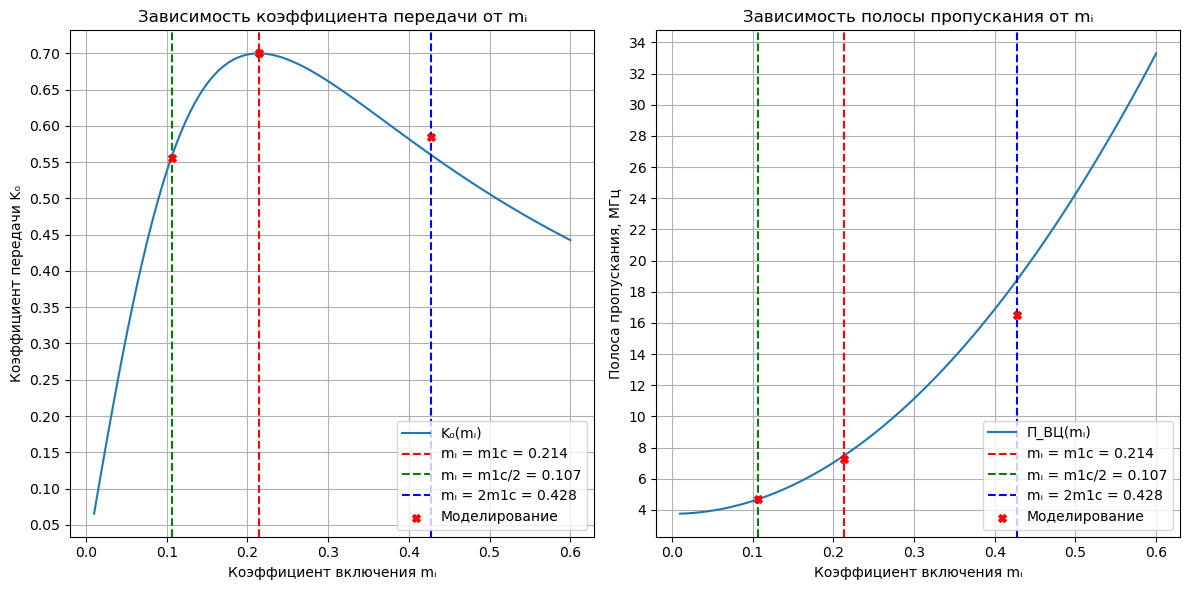


Результаты для таблицы:
| m_i        | 0.1069 | 0.2138 | 0.4275 |
| C1, пФ   | 10.86 | 12.33 | 16.94 |
| C2, пФ   | 90.72 | 45.36 | 22.68 |
| K₀       | 0.5600 | 0.7000 | 0.5600 |
| Π_ВЦ, Гц| 4687500.00 | 7500000.00 | 18750000.00 |


In [13]:
# Зависимости от mi
mi_cases = [m1c/2, m1c, 2*m1c]
mi_values = np.linspace(0.01, 0.6, 100)  # Диапазон коэффициента включения
K0_values = []
Pi_vc_values = []
Pi_vc_c = P_ke
for mi in mi_values:
    a = mi / m1c
    K0 = (2 * a * K0c) / (1 + a**2)
    Pi_vc = Pi_vc_c * (1 + a**2) / 2
    K0_values.append(K0)
    Pi_vc_values.append(Pi_vc / 1e6)  # Переводим в МГц

new_yticks_K = np.arange(0, 0.74, 0.05)
new_yticks_P = np.arange(0, 50, 2)

# Построение графиков
plt.figure(figsize=(12, 6))

# График K0
plt.subplot(1, 2, 1)
plt.plot(mi_values, K0_values, label='K₀(mᵢ)')
plt.yticks(new_yticks_K)
K0_model = [0.556, 0.7, 0.584]
plt.axvline(x=m1c, color='r', linestyle='--', label=f'mᵢ = m1с = {m1c:.3f}')
plt.axvline(x=m1c/2, color='g', linestyle='--', label=f'mᵢ = m1с/2 = {m1c/2:.3f}')
plt.axvline(x=2*m1c, color='b', linestyle='--', label=f'mᵢ = 2m1с = {2*m1c:.3f}')
# Смоделированные точки
plt.scatter(mi_cases, K0_model, marker='X', s=30, color='red', 
           label='Моделирование', zorder=5)

plt.xlabel('Коэффициент включения mᵢ')
plt.ylabel('Коэффициент передачи K₀')
plt.title('Зависимость коэффициента передачи от mᵢ')
plt.legend()
plt.grid(True)

# График Π_ВЦ
plt.subplot(1, 2, 2)
plt.plot(mi_values, Pi_vc_values, label='Π_ВЦ(mᵢ)')
plt.yticks(new_yticks_P)
plt.axvline(x=m1c, color='r', linestyle='--', label=f'mᵢ = m1с = {m1c:.3f}')
plt.axvline(x=m1c/2, color='g', linestyle='--', label=f'mᵢ = m1с/2 = {m1c/2:.3f}')
plt.axvline(x=2*m1c, color='b', linestyle='--', label=f'mᵢ = 2m1с = {2*m1c:.3f}')

Polosa_model = [4.7, 7.252, 16.489]
# Смоделированные точки
plt.scatter(mi_cases, Polosa_model, marker='X', s=30, color='red', 
           label='Моделирование', zorder=5)

plt.xlabel('Коэффициент включения mᵢ')
plt.ylabel('Полоса пропускания, МГц')
plt.title('Зависимость полосы пропускания от mᵢ')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Расчет значений для таблицы
C1_values = [Ck / (1 - mi) * 1e12 for mi in mi_cases]
C2_values = [Ck / mi * 1e12 for mi in mi_cases]

K0_table = []
Pi_vc_table = []
for mi in mi_cases:
    a = mi / m1c
    K0 = (2 * a * K0c) / (1 + a**2)
    Pi_vc = Pi_vc_c * (1 + a**2) / 2
    K0_table.append(K0)
    Pi_vc_table.append(Pi_vc)

# Вывод таблицы
print("\nРезультаты для таблицы:")
print(f"| {'m_i':<10} | {mi_cases[0]:.4f} | {mi_cases[1]:.4f} | {mi_cases[2]:.4f} |")
print(f"| C1, пФ   | {C1_values[0]:.2f} | {C1_values[1]:.2f} | {C1_values[2]:.2f} |")
print(f"| C2, пФ   | {C2_values[0]:.2f} | {C2_values[1]:.2f} | {C2_values[2]:.2f} |")
print(f"| K₀       | {K0_table[0]:.4f} | {K0_table[1]:.4f} | {K0_table[2]:.4f} |")
print(f"| Π_ВЦ, Гц| {Pi_vc_table[0]:.2f} | {Pi_vc_table[1]:.2f} | {Pi_vc_table[2]:.2f} |")